# Transformer NMT from Scratch (PyTorch)

In this notebook we build a **complete Transformer** for neural machine translation,
replacing the RNN encoder-decoder + Bahdanau attention architecture with pure attention.

### What changed from our seq2seq RNN?

| RNN + Attention | Transformer |
|---|---|
| Encoder: BiLSTM/GRU processes tokens sequentially | Encoder: self-attention processes all tokens in parallel |
| Decoder: GRU with Bahdanau cross-attention | Decoder: masked self-attention + cross-attention |
| Additive scoring: v^T tanh(W1 s + W2 h) | Scaled dot-product: QK^T / √d_k |
| Position encoded implicitly by recurrence | Position encoded explicitly with sinusoidal functions |
| One attention "head" | Multi-head attention (multiple parallel attention functions) |

We'll build each component from scratch so you can see exactly what's happening.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

%matplotlib inline

---
## 1. Positional Encoding

An RNN knows word order because it processes tokens one at a time — position is baked into the
recurrence. A Transformer sees all tokens simultaneously (like a bag of words), so we must
**explicitly inject position information** into the embeddings.

Vaswani et al. use sinusoidal functions at different frequencies:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each dimension gets a different frequency sine/cosine wave. The intuition: nearby positions have
similar encodings (the low-frequency components), but every position has a unique signature
(the high-frequency components). It's like a binary counter, but smooth.

In [2]:
class PositionalEncoding(nn.Module):
    """
    Adds positional information to token embeddings.

    Input shape:  (batch, seq_len, d_model)
    Output shape: (batch, seq_len, d_model)  — same shape, values shifted
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Pre-compute the positional encodings once (they're fixed, not learned)
        pe = torch.zeros(max_len, d_model)           # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

        # The division term: 10000^(2i/d_model), computed in log space for stability
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dimensions

        pe = pe.unsqueeze(0)  # (1, max_len, d_model) — ready to broadcast over batch
        self.register_buffer('pe', pe)  # not a parameter, but saved with model

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

---
## 2. Scaled Dot-Product Attention

This is the core operation. Compare it to Bahdanau:

**Bahdanau:** score(s_i, h_j) = v^T tanh(W1 s_i + W2 h_j)  
→ A learned feedforward net computes each score. Slow but flexible.

**Transformer:** score(q_i, k_j) = q_i · k_j / √d_k  
→ A simple dot product. Fast (matrix multiply!) but relies on the learned
projections W_Q, W_K to put queries and keys in a space where dot product is meaningful.

The √d_k scaling prevents dot products from growing large with dimension,
which would push softmax into saturated regions with tiny gradients.

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, num_heads, seq_len_q, d_k)   — "what am I looking for?"
    K: (batch, num_heads, seq_len_k, d_k)   — "what do I contain?"
    V: (batch, num_heads, seq_len_k, d_v)   — "what do I contribute?"
    mask: broadcastable to (batch, 1, seq_len_q, seq_len_k)

    Returns:
        output: (batch, num_heads, seq_len_q, d_v)
        attn_weights: (batch, num_heads, seq_len_q, seq_len_k)
    """
    d_k = K.size(-1)

    # Step 1: Score every query against every key
    # (batch, heads, seq_q, d_k) @ (batch, heads, d_k, seq_k) → (batch, heads, seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Step 2: Apply mask (if any)
    # For padding: mask out pad tokens so they get zero attention weight
    # For causal: mask out future tokens so decoder can't cheat
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Step 3: Softmax over the key dimension (last dim)
    # Each query position gets a probability distribution over all key positions
    attn_weights = F.softmax(scores, dim=-1)

    # Step 4: Weighted sum of values
    # (batch, heads, seq_q, seq_k) @ (batch, heads, seq_k, d_v) → (batch, heads, seq_q, d_v)
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

---
## 3. Multi-Head Attention

Instead of one attention function with d_model-dimensional Q, K, V, we run **h parallel
attention heads**, each with smaller dimensions d_k = d_v = d_model / h.

Why? A single attention head computes one weighted average — it can only focus on one
type of relationship at a time. Multiple heads let the model simultaneously attend to
information from different representation subspaces. One head might learn syntactic
dependencies (subject-verb), another might learn semantic ones (adjective-noun).

This module is used in **three different ways** in the Transformer:
1. **Encoder self-attention** — each source token attends to all source tokens
2. **Decoder masked self-attention** — each target token attends to previous target tokens
3. **Decoder cross-attention** — each target token attends to all source tokens
   (this is the direct replacement for Bahdanau attention!)

In [4]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention mechanism.

    The same module handles self-attention and cross-attention —
    the difference is just what you pass as Q, K, V:
      - Self-attention: Q=K=V=same sequence
      - Cross-attention: Q=decoder, K=V=encoder output
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # dimension per head

        # These are the W_Q, W_K, W_V matrices from the paper.
        # Each is (d_model, d_model) — conceptually h separate (d_model, d_k) matrices
        # packed together for efficient computation.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection: W_O in the paper
        # Concatenated heads → back to d_model dimensions
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1. Linear projections: (batch, seq_len, d_model) → (batch, seq_len, d_model)
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Reshape to separate heads:
        #    (batch, seq_len, d_model) → (batch, seq_len, num_heads, d_k)
        #    then transpose to (batch, num_heads, seq_len, d_k)
        #    so each head is an independent "mini-attention" problem
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 3. Apply attention
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # 4. Concatenate heads:
        #    (batch, num_heads, seq_len, d_k) → (batch, seq_len, num_heads, d_k)
        #    → (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, -1, self.d_model)

        # 5. Final linear projection
        output = self.W_o(attn_output)

        return output, attn_weights

---
## 4. Position-wise Feed-Forward Network

After attention, each position passes independently through a two-layer FFN:

$$FFN(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$$

The inner dimension (d_ff) is typically 4× d_model. This is where much of the
"thinking" happens — attention routes information between positions, then the FFN
processes each position's aggregated information independently.

Think of it this way: attention is about *communication* between tokens,
the FFN is about *computation* within each token's representation.

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

---
## 5. Encoder Layer

One encoder layer =  
**Self-Attention → Add & Norm → Feed-Forward → Add & Norm**

The "Add & Norm" is a **residual connection** followed by **layer normalization**.
The residual connection (x + sublayer(x)) helps gradients flow through deep stacks.
Layer norm stabilizes training by normalizing across the feature dimension.

Compare to our RNN encoder: the BiLSTM built up context sequentially through the
recurrence. Here, self-attention builds up context by letting every token directly
attend to every other token — all in one shot.

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # Self-attention: Q=K=V=x (every source token attends to every source token)
        attn_output, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout1(attn_output))  # residual + norm

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))    # residual + norm

        return x

---
## 6. Decoder Layer

One decoder layer has **three** sub-layers:

1. **Masked self-attention** — each target token attends to all *previous* target tokens.
   The mask prevents looking ahead (cheating). This is analogous to the sequential
   nature of the RNN decoder — at step k, you only know y_1 through y_{k-1}.

2. **Cross-attention** — Q comes from the decoder, K and V come from the encoder output.
   **This is the direct replacement for Bahdanau attention.**
   In Bahdanau: score(s_i, h_j) with additive scoring, context feeds into GRU.
   Here: score(q_i, k_j) with dot-product scoring, context feeds through residual.

3. **Feed-forward** — same as in the encoder.

Each sub-layer has its own Add & Norm.

In [7]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        # 1. Masked self-attention: decoder attends to itself (past tokens only)
        #    Q=K=V=x, with causal mask to prevent looking ahead
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # 2. Cross-attention: decoder attends to encoder output
        #    Q=decoder state, K=V=encoder output
        #    This is where the decoder "looks at" the source sentence —
        #    the same role Bahdanau attention played in our RNN model
        attn_output, _ = self.cross_attn(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout2(attn_output))

        # 3. Feed-forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x

---
## 7. Full Transformer Model

Now we assemble everything. The overall structure is:

```
Source tokens → Embedding + Positional Encoding → N × EncoderLayer → encoder_output

Target tokens → Embedding + Positional Encoding → N × DecoderLayer(encoder_output) → Linear → Softmax
```

Compare to our RNN:
- The RNN encoder produced hidden states h_1..h_n via recurrence. Here, self-attention does it.
- The RNN decoder produced states s_1..s_m via recurrence + attention. Here, masked self-attention
  + cross-attention does it.
- The final Dense → softmax is the same conceptually.

In [8]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=256,       # embedding dimension (paper uses 512)
        num_heads=8,       # number of attention heads
        num_layers=3,      # number of encoder/decoder layers (paper uses 6)
        d_ff=512,          # feed-forward inner dimension (paper uses 2048)
        max_len=5000,
        dropout=0.1,
        pad_idx=0
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        # Embeddings (separate for source and target vocabularies)
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)

        # Positional encoding (shared — same math for both)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        # Encoder and decoder stacks
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

        # Final projection to target vocabulary
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        """
        Padding mask for source: 1 where real tokens, 0 where padding.
        Shape: (batch, 1, 1, src_len) — broadcasts over heads and query positions.
        """
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        """
        Combined padding + causal mask for target.

        The causal mask is a lower-triangular matrix:
            [[1, 0, 0],
             [1, 1, 0],
             [1, 1, 1]]

        Position i can only attend to positions <= i.
        This enforces the autoregressive property — same constraint that the RNN
        got "for free" from sequential processing.
        """
        batch_size, tgt_len = tgt.shape

        # Padding mask
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, tgt_len)

        # Causal mask (lower triangular)
        causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)  # (1, 1, tgt_len, tgt_len)

        return pad_mask & causal_mask

    def encode(self, src, src_mask):
        """
        Encode source sequence.

        In our RNN: BiLSTM(x_1, ..., x_n) → [h_1, ..., h_n]
        Here: Embed → PosEnc → SelfAttn layers → [z_1, ..., z_n]

        The output has the same role: a sequence of contextualized representations
        of the source, one per token, that the decoder will attend to.
        """
        # Scale embeddings by √d_model (Vaswani Sec 3.4)
        x = self.src_embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        for layer in self.encoder_layers:
            x = layer(x, src_mask)

        return x

    def decode(self, tgt, encoder_output, src_mask, tgt_mask):
        """
        Decode target sequence.

        In our RNN: GRU(y_{i-1}, s_{i-1}, c_i) → s_i, then [s_i; c_i] → logits
        Here: Embed → PosEnc → (MaskedSelfAttn + CrossAttn + FFN) layers → logits

        The cross-attention in each decoder layer plays the same role as
        Bahdanau's attention context vector c_i.
        """
        x = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        for layer in self.decoder_layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)

        return x

    def forward(self, src, tgt):
        """
        Full forward pass.

        src: (batch, src_len)  — source token IDs
        tgt: (batch, tgt_len)  — target token IDs (shifted right for teacher forcing)

        Returns: (batch, tgt_len, tgt_vocab_size) — logits over target vocabulary
        """
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        encoder_output = self.encode(src, src_mask)
        decoder_output = self.decode(tgt, encoder_output, src_mask, tgt_mask)
        logits = self.output_projection(decoder_output)

        return logits

---
## 8. Smoke Test: Verify Shapes

Before training on real data, let's make sure all the tensor shapes are correct
by running random data through the model.

In [9]:
# Hyperparameters (smaller than the paper for classroom use)
SRC_VOCAB = 8000
TGT_VOCAB = 8000
D_MODEL = 256
NUM_HEADS = 8      # so d_k = 256/8 = 32 per head
NUM_LAYERS = 3
D_FF = 512
PAD_IDX = 0

model = Transformer(
    src_vocab_size=SRC_VOCAB,
    tgt_vocab_size=TGT_VOCAB,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    pad_idx=PAD_IDX
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 10,105,664
Trainable parameters: 10,105,664


In [10]:
# Fake batch: 4 source sentences of length 10, 4 target sentences of length 12
src = torch.randint(1, SRC_VOCAB, (4, 10))  # avoid 0 (pad) for this test
tgt = torch.randint(1, TGT_VOCAB, (4, 12))

print(f"Source shape: {src.shape}")  # (4, 10)
print(f"Target shape: {tgt.shape}")  # (4, 12)

logits = model(src, tgt)
print(f"Output shape: {logits.shape}")  # (4, 12, 8000)
print(f"  → batch=4, tgt_len=12, vocab={TGT_VOCAB}")
print("\nShapes look correct!")

Source shape: torch.Size([4, 10])
Target shape: torch.Size([4, 12])
Output shape: torch.Size([4, 12, 8000])
  → batch=4, tgt_len=12, vocab=8000

Shapes look correct!


---
## 9. Visualizing the Causal Mask

Let's look at what the decoder's causal mask actually looks like.
This is the mechanism that replaces the RNN's inherent sequential constraint.

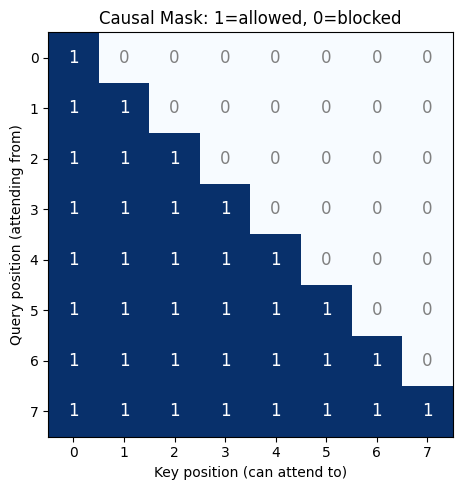

Row 0 (first token):  can only see itself
Row 3 (fourth token): can see positions 0, 1, 2, 3
Row 7 (last token):   can see everything

This is how the Transformer enforces autoregressive generation
without needing sequential processing like an RNN.


In [11]:
import matplotlib.pyplot as plt

seq_len = 8
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(causal_mask, cmap='Blues')
ax.set_xlabel('Key position (can attend to)')
ax.set_ylabel('Query position (attending from)')
ax.set_title('Causal Mask: 1=allowed, 0=blocked')

for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, int(causal_mask[i, j].item()),
                ha='center', va='center', fontsize=12,
                color='white' if causal_mask[i, j] > 0.5 else 'gray')

plt.tight_layout()
plt.show()

print("Row 0 (first token):  can only see itself")
print("Row 3 (fourth token): can see positions 0, 1, 2, 3")
print("Row 7 (last token):   can see everything")
print("\nThis is how the Transformer enforces autoregressive generation")
print("without needing sequential processing like an RNN.")

---
## 10. Training Loop Skeleton

Here's a minimal training loop. The key differences from our RNN training:
- **No teacher forcing toggle** — the Transformer always uses teacher forcing during
  training (the causal mask prevents cheating). At inference time we switch to
  autoregressive generation.
- **Learning rate warm-up** — the paper uses a custom schedule that linearly increases
  the LR for `warmup_steps`, then decreases it proportionally to the inverse square
  root of the step number. This is important for stable training.
- **Label smoothing** — soft targets instead of hard one-hot. We won't implement this
  here but it's worth knowing about.

In [12]:
def train_step(model, optimizer, src, tgt, pad_idx=0):
    """
    One training step.

    tgt_input:  [<sos>, w1, w2, ..., wn]       — what the decoder sees
    tgt_output: [w1, w2, ..., wn, <eos>]        — what we want it to predict

    This is the same shift-by-one trick as in our RNN notebook.
    """
    model.train()

    # Shift target: input is tgt[:-1], labels are tgt[1:]
    tgt_input = tgt[:, :-1]   # everything except last token
    tgt_labels = tgt[:, 1:]   # everything except first token (<sos>)

    # Forward pass
    logits = model(src, tgt_input)  # (batch, tgt_len-1, vocab_size)

    # Reshape for cross-entropy: (batch * tgt_len, vocab_size) vs (batch * tgt_len)
    logits_flat = logits.reshape(-1, logits.size(-1))
    labels_flat = tgt_labels.reshape(-1)

    loss = F.cross_entropy(logits_flat, labels_flat, ignore_index=pad_idx)

    optimizer.zero_grad()
    loss.backward()

    # Gradient clipping (important for Transformers)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item()

---
## 11. Greedy Inference (Autoregressive Generation)

At inference time, we don't have the target sequence — we generate it one token
at a time. This is **identical in spirit to our RNN decoder's inference loop**:

1. Encode the source sentence (done once)
2. Start with `<sos>` token
3. At each step, predict the next token from the model's output
4. Append that token and repeat until `<eos>` or max length

The difference is mechanical: instead of feeding into an RNN cell, we re-run
the decoder's self-attention over the growing sequence. The causal mask ensures
the computation for earlier positions doesn't change as we add new tokens
(in practice, we can cache the K, V projections — called KV caching).

In [13]:
@torch.no_grad()
def greedy_translate(model, src_tokens, sos_idx, eos_idx, max_len=50):
    """
    Greedy autoregressive translation.

    src_tokens: (1, src_len) — single source sentence, already tokenized

    Returns: list of predicted token IDs
    """
    model.eval()

    # Encode source (done once — same as computing all encoder hidden states in our RNN)
    src_mask = model.make_src_mask(src_tokens)
    encoder_output = model.encode(src_tokens, src_mask)

    # Start with <sos>
    generated = [sos_idx]

    for _ in range(max_len):
        tgt_so_far = torch.tensor([generated], dtype=torch.long, device=src_tokens.device)
        tgt_mask = model.make_tgt_mask(tgt_so_far)

        decoder_output = model.decode(tgt_so_far, encoder_output, src_mask, tgt_mask)

        # Take logits for the LAST position only
        next_token_logits = model.output_projection(decoder_output[:, -1, :])
        next_token = next_token_logits.argmax(dim=-1).item()

        generated.append(next_token)

        if next_token == eos_idx:
            break

    return generated

---
## 12. Visualizing Attention Weights

One of the best ways to understand what the model is doing is to look at
the attention weight matrices. We can extract them from any layer and head.

In [14]:
def get_attention_weights(model, src, tgt):
    """
    Run a forward pass and capture attention weights from all layers.
    Returns a dict with encoder self-attn, decoder self-attn, and cross-attn weights.
    """
    model.eval()

    src_mask = model.make_src_mask(src)
    tgt_mask = model.make_tgt_mask(tgt)

    # Encoder
    enc_self_attns = []
    x = model.src_embedding(src) * math.sqrt(model.d_model)
    x = model.pos_encoding(x)
    for layer in model.encoder_layers:
        attn_out, attn_w = layer.self_attn(x, x, x, src_mask)
        enc_self_attns.append(attn_w.detach())
        x = layer.norm1(x + layer.dropout1(attn_out))
        ff_out = layer.feed_forward(x)
        x = layer.norm2(x + layer.dropout2(ff_out))
    encoder_output = x

    # Decoder
    dec_self_attns = []
    cross_attns = []
    x = model.tgt_embedding(tgt) * math.sqrt(model.d_model)
    x = model.pos_encoding(x)
    for layer in model.decoder_layers:
        attn_out, attn_w = layer.self_attn(x, x, x, tgt_mask)
        dec_self_attns.append(attn_w.detach())
        x = layer.norm1(x + layer.dropout1(attn_out))

        attn_out, attn_w = layer.cross_attn(x, encoder_output, encoder_output, src_mask)
        cross_attns.append(attn_w.detach())
        x = layer.norm2(x + layer.dropout2(attn_out))

        ff_out = layer.feed_forward(x)
        x = layer.norm3(x + layer.dropout3(ff_out))

    return {
        'encoder_self': enc_self_attns,     # list of (batch, heads, src_len, src_len)
        'decoder_self': dec_self_attns,     # list of (batch, heads, tgt_len, tgt_len)
        'cross': cross_attns               # list of (batch, heads, tgt_len, src_len)
    }

Cross-attention (decoder → encoder), Layer 0:
(These patterns are random since the model is untrained.
 After training, you'd see diagonal-ish patterns for monotonic alignment,
 similar to the Bahdanau attention heatmaps from our RNN notebook.)


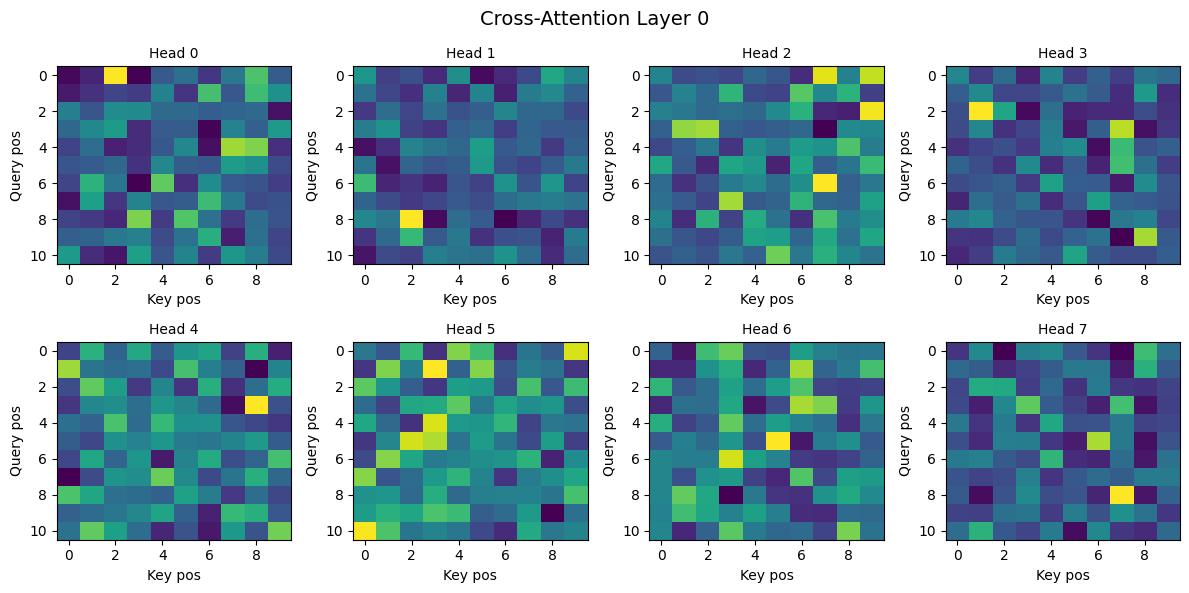

In [15]:
def plot_attention_heads(attn_weights, layer_idx=0, title_prefix=""):
    """
    Plot all attention heads for a given layer.
    attn_weights: (batch, num_heads, seq_q, seq_k) — we'll use batch item 0.
    """
    weights = attn_weights[layer_idx][0]  # (num_heads, seq_q, seq_k)
    num_heads = weights.shape[0]

    fig, axes = plt.subplots(2, num_heads // 2, figsize=(3 * num_heads // 2, 6))
    axes = axes.flatten()

    for h in range(num_heads):
        ax = axes[h]
        ax.imshow(weights[h].cpu().numpy(), cmap='viridis', aspect='auto')
        ax.set_title(f'Head {h}', fontsize=10)
        ax.set_xlabel('Key pos')
        ax.set_ylabel('Query pos')

    fig.suptitle(f'{title_prefix} Layer {layer_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()


# Example with random (untrained) model
with torch.no_grad():
    attns = get_attention_weights(model, src[:1], tgt[:1, :-1])

print("Cross-attention (decoder → encoder), Layer 0:")
print("(These patterns are random since the model is untrained.")
print(" After training, you'd see diagonal-ish patterns for monotonic alignment,")
print(" similar to the Bahdanau attention heatmaps from our RNN notebook.)")
plot_attention_heads(attns['cross'], layer_idx=0, title_prefix='Cross-Attention')

---
## Summary: RNN+Attention vs Transformer

| Aspect | RNN + Bahdanau | Transformer |
|--------|---------------|-------------|
| **How context is built** | Recurrence: h_t = f(h_{t-1}, x_t) | Self-attention: all tokens attend to all tokens |
| **Decoder→Encoder bridge** | Additive cross-attention (feeds into GRU) | Scaled dot-product cross-attention (residual connection) |
| **Position awareness** | Implicit from sequential processing | Explicit positional encoding added to embeddings |
| **Parallelism** | Sequential — can't parallelize over time steps | Fully parallel during training |
| **Long-range dependencies** | O(n) steps for distant tokens to interact | O(1) — direct attention between any two positions |
| **Computational cost** | O(n) sequential steps, O(n·d²) per step | O(n²·d) for self-attention — quadratic in sequence length |
| **Number of attention functions** | One (cross-attention only) | Three: encoder self, decoder masked self, cross |
| **Multiple perspectives** | Single attention head | Multi-head: h parallel attention functions |

### Key insight
The Transformer didn't invent attention — Bahdanau did that. The Transformer's insight
was that **attention is sufficient on its own**: you don't need recurrence at all. Replace
the sequential hidden state chain with self-attention (for building context within a
sequence) and positional encoding (for preserving order), and you get a model that's
faster to train and better at capturing long-range dependencies.

---
# Part 2: Training on Spanish-English

Now we train the Transformer on the **same Spanish-English dataset** used in our
seq2seq RNN notebook. This lets us directly compare the Transformer's translations
to those produced by the basic, bidirectional, and attention RNN models.

The data pipeline is rebuilt in PyTorch, but the preprocessing mirrors what we
did with `TextVectorization` in Keras: download `spa.txt`, split into pairs,
build vocabularies, tokenize, pad, and batch.

---
## 13. Download and Prepare the Dataset

Same dataset, same cleaning as our RNN notebook:
- Download `spa-eng.zip` from TensorFlow's data server
- Strip `¡` and `¿` (inverted punctuation)
- Shuffle with seed=42 for reproducibility
- First 100,000 pairs for training, remainder for validation

In [16]:
import os, zipfile, urllib.request, re
from collections import Counter

# Download
url = "https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
zip_path = "spa-eng.zip"
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path) as z:
    with z.open("spa-eng/spa.txt") as f:
        text = f.read().decode("utf-8")

# Clean and split — same as RNN notebook
text = text.replace("¡", "").replace("¿", "")
pairs = [line.split("\t")[:2] for line in text.splitlines()]

np.random.seed(42)
np.random.shuffle(pairs)

english_sentences = [p[0] for p in pairs]
spanish_sentences = [p[1] for p in pairs]

TRAIN_SIZE = 100_000
train_en, train_es = english_sentences[:TRAIN_SIZE], spanish_sentences[:TRAIN_SIZE]
val_en, val_es = english_sentences[TRAIN_SIZE:], spanish_sentences[TRAIN_SIZE:]

print(f"Total pairs: {len(pairs):,}")
print(f"Train: {len(train_en):,}  |  Val: {len(val_en):,}")
print(f"\nExamples:")
for i in range(3):
    print(f"  {train_en[i]}  =>  {train_es[i]}")

Total pairs: 118,964
Train: 100,000  |  Val: 18,964

Examples:
  How boring!  =>  Qué aburrimiento!
  I love sports.  =>  Adoro el deporte.
  Would you like to swap jobs?  =>  Te gustaría que intercambiemos los trabajos?


---
## 14. Build Vocabularies

We build simple word-level tokenizers with special tokens:
- `<pad>` (index 0) — padding
- `<sos>` (index 1) — start of sequence
- `<eos>` (index 2) — end of sequence
- `<unk>` (index 3) — unknown/rare words

This is equivalent to what `TextVectorization` did in Keras, just explicit.

In [17]:
class Vocabulary:
    """Simple word-level vocabulary with special tokens."""

    SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]
    PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

    def __init__(self, max_size=24000):
        self.max_size = max_size
        self.word2idx = {}
        self.idx2word = []

    def build(self, sentences):
        """Build vocabulary from a list of sentences."""
        counter = Counter()
        for sent in sentences:
            counter.update(sent.lower().split())

        # Special tokens first, then most common words
        self.idx2word = list(self.SPECIAL_TOKENS)
        for word, _ in counter.most_common(self.max_size - len(self.SPECIAL_TOKENS)):
            self.idx2word.append(word)

        self.word2idx = {w: i for i, w in enumerate(self.idx2word)}
        return self

    def encode(self, sentence, max_len=20):
        """Sentence string → list of token IDs with <sos> and <eos>."""
        words = sentence.lower().split()
        ids = [self.SOS_IDX]
        for w in words[:max_len - 2]:  # leave room for sos/eos
            ids.append(self.word2idx.get(w, self.UNK_IDX))
        ids.append(self.EOS_IDX)
        return ids

    def decode(self, ids):
        """List of token IDs → sentence string."""
        words = []
        for idx in ids:
            if idx == self.EOS_IDX:
                break
            if idx not in (self.PAD_IDX, self.SOS_IDX):
                words.append(self.idx2word[idx] if idx < len(self.idx2word) else "<unk>")
        return " ".join(words)

    def __len__(self):
        return len(self.idx2word)


# Build vocabularies on training data only
MAX_LENGTH = 50

en_vocab = Vocabulary(max_size=24000).build(train_en)
es_vocab = Vocabulary(max_size=24000).build(train_es)

print(f"English vocab size: {len(en_vocab):,}")
print(f"Spanish vocab size: {len(es_vocab):,}")
print(f"\nEnglish first 10: {en_vocab.idx2word[:10]}")
print(f"Spanish first 10: {es_vocab.idx2word[:10]}")
print(f"\nExample encoding: '{train_en[0]}'")
print(f"  → {en_vocab.encode(train_en[0])}")
print(f"  → decoded back: '{en_vocab.decode(en_vocab.encode(train_en[0]))}'")

English vocab size: 22,259
Spanish vocab size: 24,000

English first 10: ['<pad>', '<sos>', '<eos>', '<unk>', 'the', 'i', 'to', 'you', 'tom', 'a']
Spanish first 10: ['<pad>', '<sos>', '<eos>', '<unk>', 'de', 'que', 'a', 'no', 'la', 'tom']

Example encoding: 'How boring!'
  → [1, 47, 13356, 2]
  → decoded back: 'how boring!'


---
## 15. PyTorch Dataset and DataLoader

We tokenize all sentences upfront, pad to `MAX_LENGTH`, and wrap in
a standard PyTorch `Dataset`/`DataLoader`. The DataLoader handles
batching and shuffling.

In [18]:
from torch.utils.data import Dataset, DataLoader


class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len=20):
        self.pairs = []
        for src, tgt in zip(src_sentences, tgt_sentences):
            src_ids = src_vocab.encode(src, max_len)
            tgt_ids = tgt_vocab.encode(tgt, max_len)
            # Pad to max_len
            src_ids += [Vocabulary.PAD_IDX] * (max_len - len(src_ids))
            tgt_ids += [Vocabulary.PAD_IDX] * (max_len - len(tgt_ids))
            self.pairs.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


BATCH_SIZE = 64

train_dataset = TranslationDataset(train_en, train_es, en_vocab, es_vocab, MAX_LENGTH)
val_dataset = TranslationDataset(val_en, val_es, en_vocab, es_vocab, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify
src_batch, tgt_batch = next(iter(train_loader))
print(f"Source batch shape: {src_batch.shape}")   # (64, 20)
print(f"Target batch shape: {tgt_batch.shape}")   # (64, 20)
print(f"\nFirst source sentence (IDs): {src_batch[0].tolist()}")
print(f"  Decoded: '{en_vocab.decode(src_batch[0].tolist())}'")
print(f"\nFirst target sentence (IDs): {tgt_batch[0].tolist()}")
print(f"  Decoded: '{es_vocab.decode(tgt_batch[0].tolist())}'")

Source batch shape: torch.Size([64, 50])
Target batch shape: torch.Size([64, 50])

First source sentence (IDs): [1, 48, 9, 472, 13, 3174, 11, 69, 796, 31, 57, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Decoded: 'as a matter of fact, he doesn't agree with me.'

First target sentence (IDs): [1, 11, 4727, 18, 7, 22, 4, 377, 371, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Decoded: 'en realidad, él no está de acuerdo conmigo.'


---
## 16. Instantiate the Transformer

We use the same `Transformer` class defined above, now with real vocabulary sizes.
We also set up the Vaswani learning rate schedule: linear warmup followed by
inverse-sqrt decay.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

D_MODEL = 512
NUM_HEADS = 8      # d_k = 64 per head
NUM_LAYERS = 4
D_FF = 1024
DROPOUT = 0.1

model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(es_vocab),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=Vocabulary.PAD_IDX
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Using device: cuda
Trainable parameters: 57,025,472


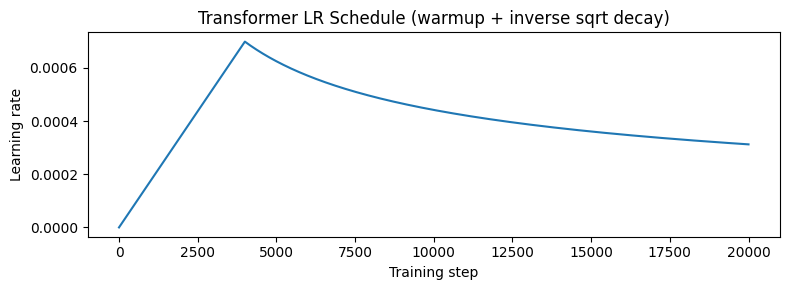

In [20]:
# Vaswani learning rate schedule: warmup then inverse sqrt decay
# lrate = d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))

class TransformerLRScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = self.d_model ** (-0.5) * min(
            self.step_num ** (-0.5),
            self.step_num * self.warmup_steps ** (-1.5)
        )
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr


optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = TransformerLRScheduler(optimizer, D_MODEL, warmup_steps=4000)

# Visualize the LR schedule
lrs = []
temp_sched = TransformerLRScheduler(optimizer, D_MODEL, warmup_steps=4000)
for _ in range(20000):
    lrs.append(temp_sched.step())

plt.figure(figsize=(8, 3))
plt.plot(lrs)
plt.xlabel('Training step')
plt.ylabel('Learning rate')
plt.title('Transformer LR Schedule (warmup + inverse sqrt decay)')
plt.tight_layout()
plt.show()

# Reset for actual training
optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = TransformerLRScheduler(optimizer, D_MODEL, warmup_steps=4000)

---
## 17. Training Loop

We use the `train_step` function defined earlier (Section 10).
The loop adds validation loss tracking, periodic translation samples,
and best-model checkpointing.

In [21]:
def evaluate(model, val_loader, pad_idx=0):
    """Compute average validation loss."""
    model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_labels = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                tgt_labels.reshape(-1),
                ignore_index=pad_idx,
                label_smoothing=0.1,
            )
            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches

In [22]:
# Same test sentences as the RNN notebook for direct comparison
test_sentences = [
    "I like soccer.",
    "How are you?",
    "How are you, pal?",
    "The weather is nice today.",
    "I want to learn Spanish.",
    "Where is the library?",
    "We can order dinner but I don't want pizza.",
    "The only thing we have to fear is fear itself"
]


def translate_sentence(model, sentence, src_vocab, tgt_vocab, max_len=50):
    """Translate a single English sentence to Spanish using greedy decoding."""
    model.eval()

    # Tokenize source
    src_ids = src_vocab.encode(sentence, MAX_LENGTH)
    src_ids += [Vocabulary.PAD_IDX] * (MAX_LENGTH - len(src_ids))
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

    # Use the greedy_translate function from Section 11
    output_ids = greedy_translate(
        model, src_tensor,
        sos_idx=Vocabulary.SOS_IDX,
        eos_idx=Vocabulary.EOS_IDX,
        max_len=max_len
    )

    return tgt_vocab.decode(output_ids)


def show_sample_translations(model, label=""):
    """Translate test sentences and display results."""
    if label:
        print(f"\n{'=' * 60}")
        print(f"{label}")
        print(f"{'=' * 60}")
    for sent in test_sentences:
        translation = translate_sentence(model, sent, en_vocab, es_vocab)
        print(f"  EN: {sent}")
        print(f"  ES: {translation}")
        print()

In [29]:
from tensorflow.keras.utils import Progbar

NUM_EPOCHS = 5

best_val_loss = float('inf')
train_losses = []
val_losses = []

print("Before training:")
show_sample_translations(model, "Untrained Model (random output)")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0
    num_batches = 0
    progress_bar = Progbar(target=len(train_loader), stateful_metrics=["lr"])

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    for batch_idx, (src, tgt) in enumerate(train_loader):
        src, tgt = src.to(device), tgt.to(device)

        # Use train_step from Section 10
        loss = train_step(model, optimizer, src, tgt, pad_idx=Vocabulary.PAD_IDX)

        # Update learning rate (Vaswani schedule)
        lr = scheduler.step()

        epoch_loss += loss
        num_batches += 1
        avg_loss = epoch_loss / num_batches
        progress_bar.update(batch_idx + 1, values=[("loss", avg_loss), ("lr", lr)])

    # Epoch stats
    avg_train_loss = epoch_loss / num_batches
    avg_val_loss = evaluate(model, val_loader, pad_idx=Vocabulary.PAD_IDX)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS}  |  "
          f"Train Loss: {avg_train_loss:.4f}  |  Val Loss: {avg_val_loss:.4f}")

    # Checkpoint best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "transformer_nmt_best.pt")
        print(f"  ✓ New best model saved (val_loss={avg_val_loss:.4f})")

    # Sample translations every epoch
    show_sample_translations(model, f"Translations after epoch {epoch}")
    print()

Before training:

Untrained Model (random output)
  EN: I like soccer.
  ES: me gusta el fútbol.

  EN: How are you?
  ES: cómo te están <unk>

  EN: How are you, pal?
  ES: cómo se están <unk>

  EN: The weather is nice today.
  ES: el buen tiempo, hoy.

  EN: I want to learn Spanish.
  ES: quiero aprender español.

  EN: Where is the library?
  ES: dónde está la biblioteca?

  EN: We can order dinner but I don't want pizza.
  ES: no quiero que podemos hacerlo.

  EN: The only thing we have to fear is fear itself
  ES: la cosa es lo único que tenemos que hacerlo.


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - loss: 2.5781 - lr: 5.5893e-04
Epoch 1/5  |  Train Loss: 2.6031  |  Val Loss: 3.8445
  ✓ New best model saved (val_loss=3.8445)

Translations after epoch 1
  EN: I like soccer.
  ES: me gusta el fútbol.

  EN: How are you?
  ES: cómo te están ustedes?

  EN: How are you, pal?
  ES: cómo te está a la habitación.

  EN: The weather is nice today.
  ES: hoy es un buen bue

---
## 18. Training Curves

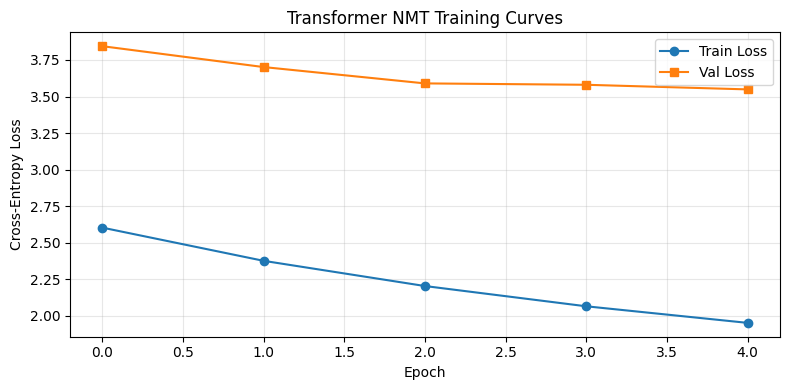

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer NMT Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 19. Final Evaluation with Best Model

Load the best checkpoint and run the full test set.

In [31]:
# Load best model
model.load_state_dict(torch.load("transformer_nmt_best.pt", map_location=device))
print(f"Loaded best model (val_loss={best_val_loss:.4f})")

show_sample_translations(model, "Final Transformer Translations (best checkpoint)")

Loaded best model (val_loss=3.5486)

Final Transformer Translations (best checkpoint)
  EN: I like soccer.
  ES: me gusta el fútbol.

  EN: How are you?
  ES: cómo es usted?

  EN: How are you, pal?
  ES: cómo te estás <unk>

  EN: The weather is nice today.
  ES: hoy hace buen tiempo.

  EN: I want to learn Spanish.
  ES: quiero aprender español.

  EN: Where is the library?
  ES: dónde está la biblioteca?

  EN: We can order dinner but I don't want pizza.
  ES: no quiero la cena pero lo que podemos <unk>

  EN: The only thing we have to fear is fear itself
  ES: lo único que tenemos que hacer es que le tenemos que le temo a la hermana.



---
## 20. Visualize Trained Attention Patterns

Now that the model is trained, the cross-attention weights should show meaningful
alignment patterns — similar to the Bahdanau attention heatmaps from the RNN notebook.
Diagonal-ish patterns indicate monotonic alignment (word order roughly preserved),
while off-diagonal patterns show reordering.

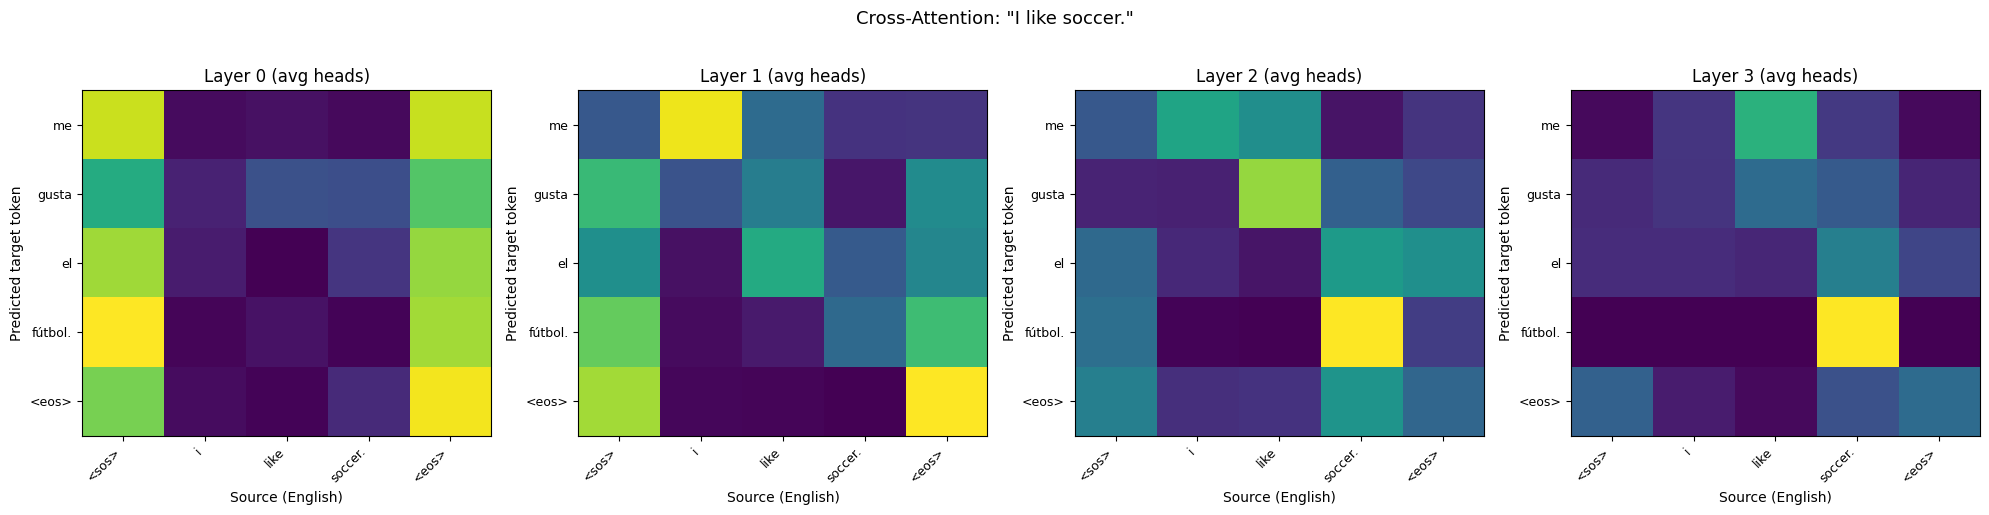

  EN: I like soccer.
  ES: me gusta el fútbol.



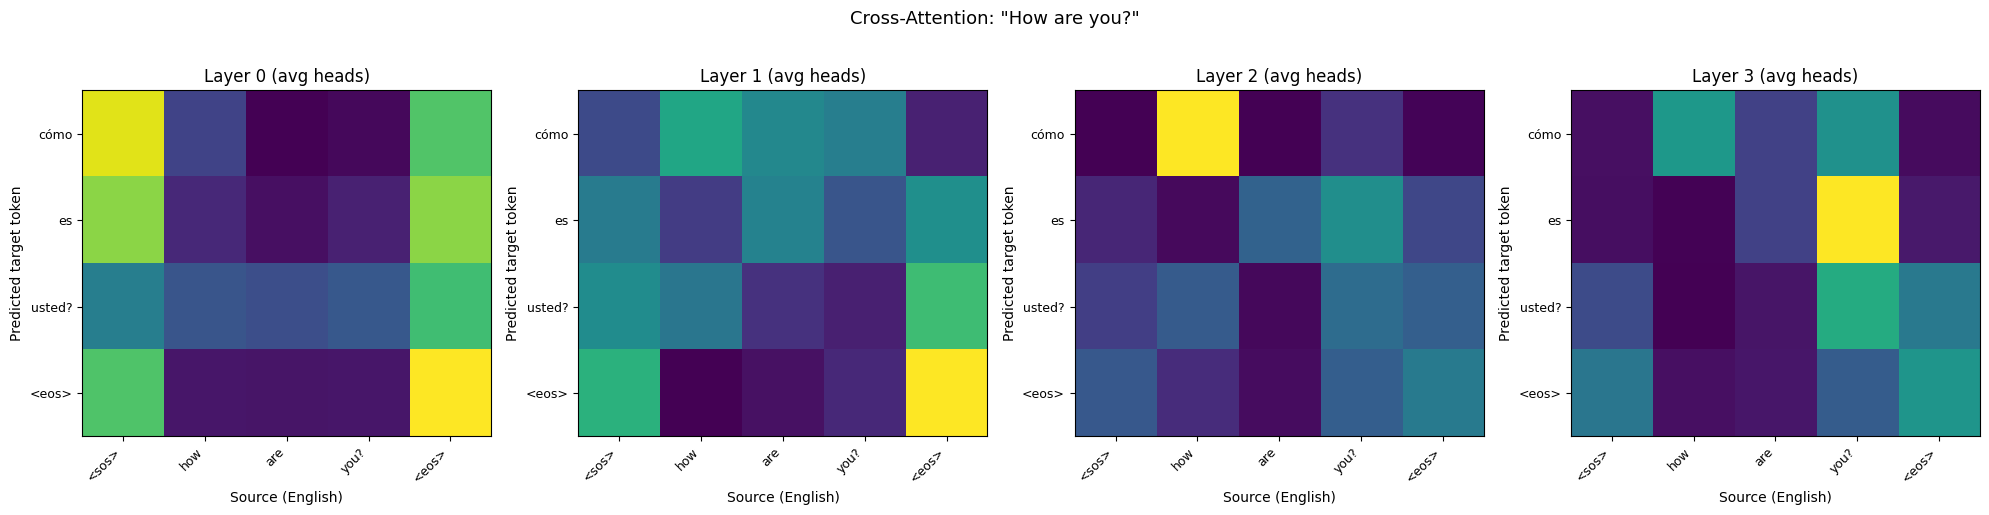

  EN: How are you?
  ES: cómo es usted?



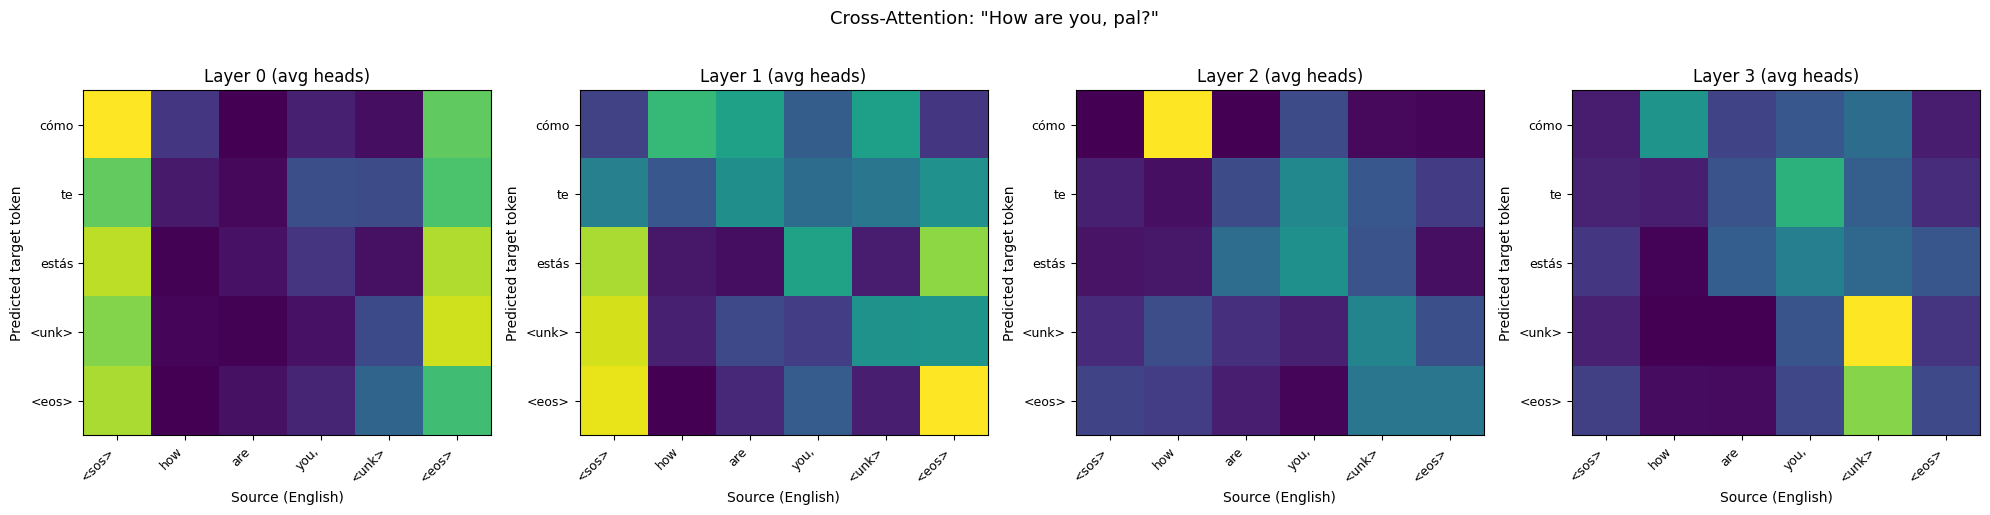

  EN: How are you, pal?
  ES: cómo te estás <unk>



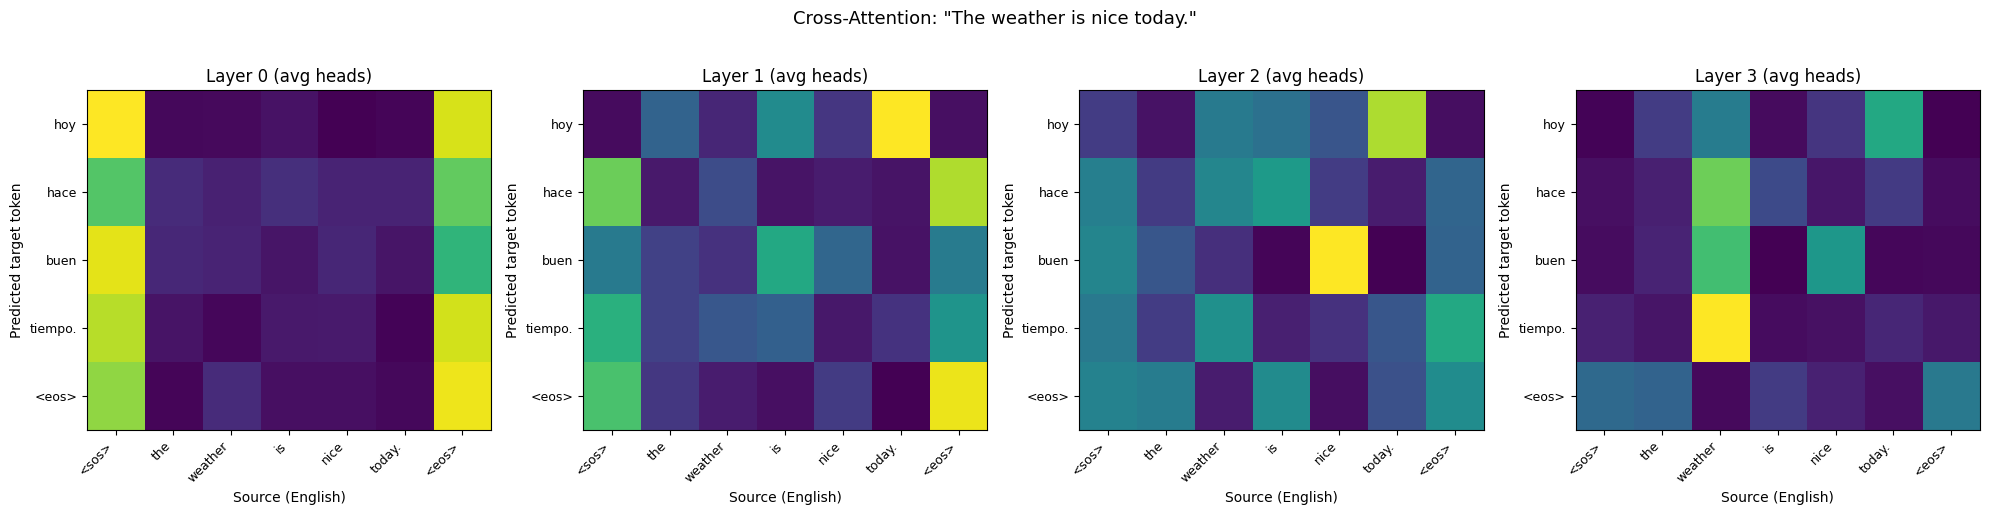

  EN: The weather is nice today.
  ES: hoy hace buen tiempo.



In [32]:
def visualize_translation_attention(model, sentence, src_vocab, tgt_vocab):
    """
    Translate a sentence and visualize the cross-attention alignment.
    Uses get_attention_weights from Section 12.
    """
    model.eval()

    def ids_to_tokens(vocab, ids):
        return [vocab.idx2word[idx] if idx < len(vocab.idx2word) else "<unk>" for idx in ids]

    # Encode source
    src_ids = src_vocab.encode(sentence, MAX_LENGTH)
    src_ids += [Vocabulary.PAD_IDX] * (MAX_LENGTH - len(src_ids))
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

    # Generate translation
    output_ids = greedy_translate(
        model, src_tensor,
        sos_idx=Vocabulary.SOS_IDX,
        eos_idx=Vocabulary.EOS_IDX
    )

    # Cross-attention rows correspond to decoder input positions, which produce
    # the next target token. Label rows with the predicted tokens to avoid a
    # one-step shift in the visualization.
    tgt_input_ids = output_ids[:-1]
    tgt_pred_ids = output_ids[1:]
    tgt_tensor = torch.tensor([tgt_input_ids], dtype=torch.long, device=device)
    attns = get_attention_weights(model, src_tensor, tgt_tensor)

    # Trim source labels to the actual encoded sequence, including <sos>/<eos>.
    src_eos_pos = src_ids.index(Vocabulary.EOS_IDX) if Vocabulary.EOS_IDX in src_ids else len(src_ids)
    src_labels = ids_to_tokens(src_vocab, src_ids[:src_eos_pos + 1])
    tgt_labels = ids_to_tokens(tgt_vocab, tgt_pred_ids)

    src_len = len(src_labels)
    tgt_len = len(tgt_labels)

    # Plot cross-attention for each layer, averaged across heads.
    num_layers = len(attns['cross'])
    fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 5))
    if num_layers == 1:
        axes = [axes]

    for layer_idx, ax in enumerate(axes):
        weights = attns['cross'][layer_idx][0].mean(dim=0)
        weights = weights[:tgt_len, :src_len].cpu().numpy()

        ax.imshow(weights, cmap='viridis', aspect='auto')
        ax.set_xticks(range(src_len))
        ax.set_xticklabels(src_labels, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(tgt_len))
        ax.set_yticklabels(tgt_labels, fontsize=9)
        ax.set_xlabel('Source (English)')
        ax.set_ylabel('Predicted target token')
        ax.set_title(f'Layer {layer_idx} (avg heads)')

    fig.suptitle(f'Cross-Attention: "{sentence}"', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  EN: {sentence}")
    print(f"  ES: {tgt_vocab.decode(output_ids)}")


# Visualize a few translations
for sent in test_sentences[:4]:
    visualize_translation_attention(model, sent, en_vocab, es_vocab)
    print()

---
## 21. Comparing Individual Attention Heads

Each head can learn to attend to different types of relationships.
Let's look at all 8 heads in the last decoder layer's cross-attention
for a single sentence.

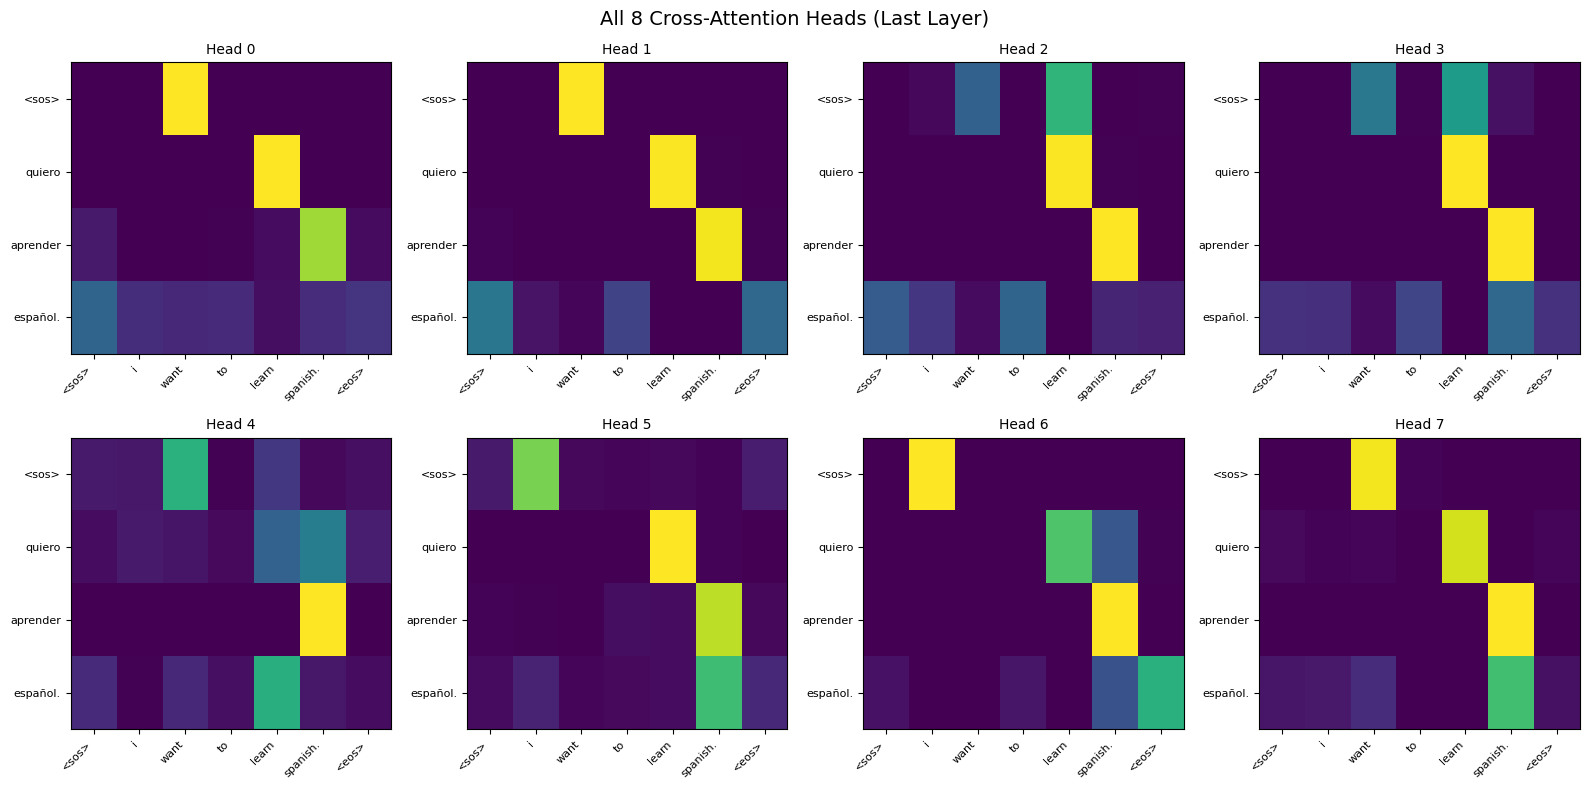

Notice how different heads attend to different aspects of the source.
Some may show diagonal alignment, others may focus on specific words.


In [27]:
sentence = "I want to learn Spanish."


def ids_to_tokens(vocab, ids):
    return [vocab.idx2word[idx] if idx < len(vocab.idx2word) else "<unk>" for idx in ids]


# Encode and translate
src_ids = en_vocab.encode(sentence, MAX_LENGTH)
src_ids += [Vocabulary.PAD_IDX] * (MAX_LENGTH - len(src_ids))
src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

output_ids = greedy_translate(
    model, src_tensor,
    sos_idx=Vocabulary.SOS_IDX,
    eos_idx=Vocabulary.EOS_IDX
)

tgt_input_ids = output_ids[:-1]
tgt_pred_ids = output_ids[1:]
tgt_tensor = torch.tensor([tgt_input_ids], dtype=torch.long, device=device)
attns = get_attention_weights(model, src_tensor, tgt_tensor)

src_eos_pos = src_ids.index(Vocabulary.EOS_IDX) if Vocabulary.EOS_IDX in src_ids else len(src_ids)
src_words = ids_to_tokens(en_vocab, src_ids[:src_eos_pos + 1])
tgt_words = ids_to_tokens(es_vocab, tgt_pred_ids)
src_len = len(src_words)
tgt_len = len(tgt_words)

# Plot all heads from the last cross-attention layer
last_layer_attn = attns['cross'][-1][0]  # (num_heads, tgt_len_full, src_len_full)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for h, ax in enumerate(axes.flatten()):
    weights = last_layer_attn[h, :tgt_len, :src_len].cpu().numpy()
    ax.imshow(weights, cmap='viridis', aspect='auto')
    ax.set_xticks(range(src_len))
    ax.set_xticklabels(src_words, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(tgt_len))
    ax.set_yticklabels(tgt_words, fontsize=8)
    ax.set_title(f'Head {h}', fontsize=10)

fig.suptitle('All 8 Cross-Attention Heads (Last Layer)', fontsize=14)
plt.tight_layout()
plt.show()

print("Rows now correspond to the target tokens predicted at each step.")
print("That removes the apparent one-token shift from the earlier version.")

---
## Discussion: Comparing to Our RNN Models

Run the same test sentences through the RNN notebook's models and compare:

1. **Translation quality** — How do the Transformer translations compare to basic,
   bidirectional, and attention RNN models?

2. **Training speed** — The Transformer processes all positions in parallel during
   training. How does wall-clock time per epoch compare to the LSTM models?

3. **Attention patterns** — The cross-attention heatmaps above play the same role as
   the Bahdanau attention visualizations. Do you see similar alignment patterns?
   How do different heads specialize?

4. **Long sentences** — Try some longer inputs. The Transformer should handle them
   better than the basic RNN (no information bottleneck) and comparably to the
   attention RNN. The O(1) path length between any two positions means long-range
   dependencies are captured more directly.

5. **Parameter count** — Compare the parameter counts. The Transformer has no
   recurrent weights, but the attention projections and feed-forward layers
   add up. Is it bigger or smaller than the LSTM models?

### What we built

We started the semester with a basic encoder-decoder RNN that compressed an
entire sentence into a single vector. We added Bahdanau attention to let the
decoder look back at every encoder state. And now we've removed the RNN
entirely, replacing recurrence with self-attention and positional encoding.

The progression: **fixed context → dynamic context → attention is all you need.**